In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [2]:
X = pd.read_csv("features.csv")
y = pd.read_csv("target.csv")

In [3]:
y = y.values

In [4]:
### split the data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, stratify = y, random_state = 42)

### Data Preprocessing

In [5]:
### Group the objects and the numeric type
num_list = X_train.select_dtypes(include = "number").drop(columns = "Pest_Presence").columns.to_list()
#### object data types
cat_list = X_train.select_dtypes(include = "object").columns.to_list()
pest_col = ["Pest_Presence"]

In [6]:
### Focus on the numeric part
num_steps = Pipeline([("impute", SimpleImputer(strategy = "mean")),("scaling", StandardScaler())])
cat_steps = Pipeline([("impute", SimpleImputer(strategy = "most_frequent")), 
                      ("encode", OneHotEncoder(drop = "first"))])
pest_steps = Pipeline([("impute", SimpleImputer(strategy = "most_frequent"))])

In [7]:
### Use the columntransformer to identify and effect the changes to the columns
preprocessor = ColumnTransformer([("num_transform", num_steps, num_list),("cat_transform", cat_steps, cat_list),
                   ("pest_transform", pest_steps, pest_col)])

### Random Forest

In [8]:
### Random Forest
model_forest = Pipeline([("column_transform", preprocessor), ("smote", SMOTE(random_state = 42)),
          ("classifier", RandomForestClassifier(random_state = 42))])

In [9]:
#### fit the model
model_forest.fit(X_train, y_train)

,steps,"[('column_transform', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Feature Importance
- We want to know how the independent variables(features) are contributing to the dependent variable(target). We will tell that from their coefficient

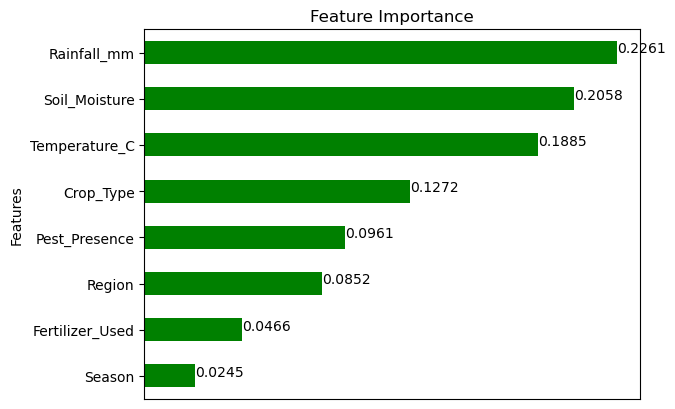

In [10]:
### extract the features used in the model
features = model_forest.named_steps["column_transform"].get_feature_names_out()
coef = model_forest.named_steps["classifier"].feature_importances_
fi = pd.DataFrame({"Features":features, "Coefficient":coef})
fi["Features"] = fi["Features"].str.split("__").str[1]
fi["Features"] = fi["Features"].str.split("_").str[:2].str.join("_")
fi.loc[fi["Features"].str.startswith("Region"), "Features"] = "Region"
### group the like values
group_fi = fi.groupby("Features")["Coefficient"].sum().sort_values()

### plot the feature importance
group_fi.plot(kind = "barh", color = "g")
plt.title("Feature Importance")
### Data label
for x, y in enumerate(group_fi):
    plt.text(y, x, f"{y:.4f}")
    
plt.xticks([])   
plt.show()

### Model Evaluation

In [11]:
y_pred = model_forest.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.44      0.50      0.47       108
         1.0       0.83      0.79      0.81       331

    accuracy                           0.72       439
   macro avg       0.63      0.64      0.64       439
weighted avg       0.73      0.72      0.72       439



### Hyperparameter tuning

### Grid Search CV

In [13]:
### using the random forest on the best model
random_grid = {
"classifier__n_estimators":[50,100,150],
"classifier__max_depth":[3,5,None],
"classifier__min_samples_split":[2,5],
"classifier__min_samples_leaf":[1,2,5],
"classifier__class_weight":["balanced"]}

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
search_grid = GridSearchCV(estimator = model_forest, param_grid = random_grid, cv = 5, scoring = "f1")

In [16]:
### fit the model
search_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': ['balanced'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5], ...}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num_transform', ...), ('cat_transform', ...), ...]"


In [17]:
best_model = search_grid.best_estimator_

In [18]:
y_pred_grid = best_model.predict(X_test)

In [19]:
print(classification_report)

<function classification_report at 0x0000024AFDB1F1A0>


In [20]:
### Extract the parameters
search_grid.best_params_

{'classifier__class_weight': 'balanced',
 'classifier__max_depth': None,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 100}